<a href="https://colab.research.google.com/github/stvngo/Pivotal-Token-Representation-Learning/blob/main/notebooks/steering_gsm8k_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pivotal-Token Steering on Qwen3-0.6B — GSM8K Evaluation

Interactive, checkpointed port of the steering + evaluation pipeline from the `Pivotal-Token-Representation-Learning` repo. Designed to run unchanged on:

- **Google Colab** (free GPU works well; CPU works but is slow)
- **Kaggle / SageMaker Studio / RunPod** (any Jupyter kernel)

### What it does

1. Loads Qwen3-0.6B from Hugging Face — never caches the model into the repo.
2. Loads a pre-computed **pivotal-token steering vector** (centroid difference at layer 14, the best-performing probe layer with AUROC 0.808 on the probing task).
3. Runs a paired GSM8K evaluation of the base model vs. the same model with the steering vector added at that layer with factors `{1.2, 1.4, 1.6, 1.8, 2.0, 0.0, -1.0}`.
   * `factor = 1 + α`, where `α` is the coefficient added to the pivotal direction.
   * `factor = 1.2` → mild amplification; `factor = 2.0` → strong amplification; `factor = 0` → ablation of the pivotal direction; `factor = -1` → anti-steering.
4. Reports **accuracy**, **binary F1** (correct-vs-not), and **answer parse-rate**.
5. Produces error-analysis plots and saves all intermediate artifacts to `./nb_results/`.

Each heavy cell caches its output to disk, so re-running the notebook only regenerates what's missing (set `FORCE_RERUN = True` in the config cell to redo everything).

## 1. Install dependencies

In [1]:
# Run once per runtime. Safe to skip if already installed.
%pip install -q "transformers>=4.44" datasets accelerate matplotlib seaborn scikit-learn tqdm pandas

## 2. Imports, seeding, device detection

In [2]:
import json
import os
import random
import sys
import time
import zipfile
from pathlib import Path

import numpy as np
import torch
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

if torch.cuda.is_available():
    DEVICE = "cuda"
    DTYPE = torch.bfloat16
elif getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
    DEVICE = "mps"
    DTYPE = torch.float32
else:
    DEVICE = "cpu"
    DTYPE = torch.float32

RESULTS_DIR = Path("nb_results")
RESULTS_DIR.mkdir(exist_ok=True)

print(f"device={DEVICE} dtype={DTYPE}")
print(f"results -> {RESULTS_DIR.resolve()}")

device=cuda dtype=torch.bfloat16
results -> /content/nb_results


## 3. Experiment configuration

Edit here if you want to sweep a different layer, factor set, or example count. All downstream cells reference these globals.

In [3]:
MODEL_NAME = "Qwen/Qwen3-0.6B"
LAYER = 14  # top-performing probe layer (AUROC 0.808 on the probing task)
FACTORS = [1.2, 1.4, 1.6, 1.8, 2.0, 0.0, -1.0]
MAX_EXAMPLES = 100
MAX_NEW_TOKENS = 256
TEMPERATURE = 0.6
TOP_P = 0.9

# Where to fetch the pre-computed steering vector. Fallback order:
#   1. LOCAL_PROBE_DIR (repo is cloned)
#   2. PROBE_RAW_URL_BASE + filename (GitHub raw download)
#   3. Manual upload (uncomment the cell below the probe loader)
LOCAL_PROBE_DIR = Path("artifacts/cached3/sklearn/steering_configs")
PROBE_RAW_URL_BASE = (
    "https://raw.githubusercontent.com/"
    "stvngo/Pivotal-Token-Representation-Learning/"
    "main/artifacts/cached3/sklearn/steering_configs/"
)

FORCE_RERUN = False  # set True to ignore cached results in nb_results/

## 4. Load the pre-computed steering probe

In [4]:
import urllib.request


def _try_local_probe(layer: int):
    cfg_path = LOCAL_PROBE_DIR / f"steering_layer{layer}.json"
    vec_path = LOCAL_PROBE_DIR / f"steering_layer{layer}_vector.npy"
    if cfg_path.exists() and vec_path.exists():
        return cfg_path, vec_path
    return None, None


def _try_remote_probe(layer: int, dest_dir: Path):
    dest_dir.mkdir(parents=True, exist_ok=True)
    cfg_name = f"steering_layer{layer}.json"
    vec_name = f"steering_layer{layer}_vector.npy"
    try:
        urllib.request.urlretrieve(PROBE_RAW_URL_BASE + cfg_name, dest_dir / cfg_name)
        urllib.request.urlretrieve(PROBE_RAW_URL_BASE + vec_name, dest_dir / vec_name)
        return dest_dir / cfg_name, dest_dir / vec_name
    except Exception as exc:
        print(f"Remote fetch failed: {exc}")
        return None, None


_probe_dir = RESULTS_DIR / "probes"
cfg_path, vec_path = _try_local_probe(LAYER)
if cfg_path is None:
    cfg_path, vec_path = _try_remote_probe(LAYER, _probe_dir)

assert cfg_path is not None and vec_path is not None, (
    "Could not locate steering probe. Either clone the repo so LOCAL_PROBE_DIR exists, "
    "set PROBE_RAW_URL_BASE to a reachable GitHub raw URL, or uncomment the manual-upload cell below."
)

with cfg_path.open("r") as f:
    steering_cfg = json.load(f)
steering_vector = np.load(vec_path).astype(np.float32)

print(f"Loaded probe config from {cfg_path}")
print(f"  layer       = {steering_cfg['layer']}")
print(f"  vector_type = {steering_cfg['vector_type']}")
print(f"  hidden_dim  = {steering_cfg['hidden_dim']}")
print(f"  vector_norm = {steering_cfg['vector_norm']:.4f}")
assert steering_cfg["hidden_dim"] == steering_vector.shape[0]

Loaded probe config from nb_results/probes/steering_layer14.json
  layer       = 14
  vector_type = centroid_diff
  hidden_dim  = 1024
  vector_norm = 9.5937


In [5]:
# --- Google Colab: upload your own probe --------------------------------
# Uncomment the three lines below to upload a `steering_layer{N}.json` and
# matching `steering_layer{N}_vector.npy` from your local machine. The files
# land in the current working directory; set LOCAL_PROBE_DIR = Path('.') in the
# config cell above and re-run the probe loader.
#
# from google.colab import files
# uploaded = files.upload()
# print('Uploaded:', list(uploaded.keys()))

## 5. Load Qwen3-0.6B from Hugging Face

In [6]:
from transformers import AutoModelForCausalLM, AutoTokenizer

_t0 = time.time()
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=DTYPE,
    trust_remote_code=True,
    low_cpu_mem_usage=True,
).to(DEVICE)
model.eval()
if tokenizer.pad_token_id is None:
    tokenizer.pad_token_id = tokenizer.eos_token_id

n_params = sum(p.numel() for p in model.parameters())
print(f"Loaded {MODEL_NAME} on {DEVICE} ({DTYPE}) in {time.time() - _t0:.1f}s")
print(f"  params            = {n_params / 1e9:.3f}B")
print(f"  hidden_size       = {model.config.hidden_size}")
print(f"  num_hidden_layers = {model.config.num_hidden_layers}")
assert steering_vector.shape[0] == model.config.hidden_size, (
    f"Probe hidden_dim {steering_vector.shape[0]} ≠ model hidden_size {model.config.hidden_size}"
)

config.json:   0%|          | 0.00/726 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/1.50G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Loaded Qwen/Qwen3-0.6B on cuda (torch.bfloat16) in 21.2s
  params            = 0.752B
  hidden_size       = 1024
  num_hidden_layers = 28


## 6. Steering hooks

Ported verbatim from `probe_pipeline/steering.py` so the notebook is self-contained. We register a forward hook on the layer's *output*; the hook adds `strength * v` to every token's hidden state, where `strength = factor - 1.0`.

In [ ]:
import torch
import torch.nn as nn

# Pull the canonical, off-by-one-fixed hook factory from probe_pipeline.steering
# (issues #2 + #7 in docs/issues.md). If the local checkout isn't on sys.path
# (e.g. fresh Colab runtime), fall back to a vendored copy with the same fix.
try:
    from probe_pipeline.steering import _get_decoder_layer, make_hook  # noqa: F401
    print("[hooks] using probe_pipeline.steering (post-Issue-#2/#7 fix)")
except Exception:
    print("[hooks] probe_pipeline not importable, vendoring local fix")

    def _get_decoder_layer(mdl: nn.Module, layer_idx: int) -> nn.Module:
        """Returns the module whose forward-hook output IS hidden_states[layer_idx].

        Post-Issue-#2: layers[layer_idx-1] for layer_idx>=1; embed_tokens for 0.
        """
        if hasattr(mdl, "model") and hasattr(mdl.model, "layers"):
            if layer_idx == 0:
                return mdl.model.embed_tokens
            return mdl.model.layers[layer_idx - 1]
        if hasattr(mdl, "transformer") and hasattr(mdl.transformer, "h"):
            if layer_idx == 0:
                return mdl.transformer.wte
            return mdl.transformer.h[layer_idx - 1]
        raise AttributeError(f"Cannot find decoder layers in {type(mdl)}")

    def make_hook(vector, coef, mode="additive_normalized", position_mask=None):
        if mode not in {"additive_raw", "additive_normalized", "projection"}:
            raise ValueError(f"unknown mode {mode!r}")

        def hook(_module, _args, output):
            hidden = output[0] if isinstance(output, tuple) else output
            v = vector.to(hidden.device).to(hidden.dtype)
            if v.dim() == 1:
                v_full = v.view(1, 1, -1)
            else:
                v_full = v
            if mode == "additive_raw":
                delta = coef * v_full
            elif mode == "additive_normalized":
                v_hat = v / (v.norm() + 1e-8)
                v_hat_b = v_hat.view(1, 1, -1)
                h_norm = hidden.norm(dim=-1, keepdim=True)
                delta = coef * h_norm * v_hat_b
            else:  # projection
                v_hat = v / (v.norm() + 1e-8)
                v_hat_b = v_hat.view(1, 1, -1)
                proj = (hidden * v_hat_b).sum(dim=-1, keepdim=True)
                delta = (coef - 1.0) * proj * v_hat_b
            if position_mask is not None:
                if position_mask.dim() == 1:
                    pm = position_mask.view(1, -1, 1)
                else:
                    pm = position_mask.unsqueeze(-1)
                delta = delta * pm.to(device=hidden.device, dtype=hidden.dtype)
            new_hidden = hidden + delta
            if isinstance(output, tuple):
                return (new_hidden,) + output[1:]
            return new_hidden
        return hook


# ---- thin wrappers that preserve legacy notebook entry points ---------------

# STEERING_MODE controls which convention the *_steering helpers below use.
# Default "additive_normalized" follows the Issue-#7 plan ("canonical default
# for new runs"). Set to "additive_raw" in the notebook BEFORE re-running its
# steered cells if you need the legacy convention for an apples-to-apples
# overlay with the pre-fix runs in artifacts/notebook_runs/REGISTRY.md.
STEERING_MODE = "additive_normalized"


def register_steering(mdl, layer: int, vector, coef: float, mode: str | None = None):
    """Register a single forward hook at ``layer``. ``coef`` is the value we
    pass into ``make_hook``: for ``additive_raw`` that's the legacy
    ``factor - 1.0``; for ``additive_normalized`` it's the unitless per-token
    coefficient on ``||h|| * v_hat``; for ``projection`` it's ``alpha`` (where
    alpha=1 is identity and alpha=0 ablates).
    """
    return [
        _get_decoder_layer(mdl, layer).register_forward_hook(
            make_hook(vector, coef, mode=(mode or STEERING_MODE))
        )
    ]


def register_additive_hooks(mdl, injections, mode: str | None = None):
    """One additive hook per (layer_idx, vector, coef) tuple."""
    handles = []
    for layer_idx, vector, coef in injections:
        handles.append(
            _get_decoder_layer(mdl, layer_idx).register_forward_hook(
                make_hook(vector, coef, mode=(mode or STEERING_MODE))
            )
        )
    return handles


def remove_hooks(handles):
    for h in handles:
        h.remove()


# Probe-weights notebook keeps its own additive/projection helper names so
# section 11/12/15 cells in that notebook don't need rewriting.
def make_additive_hook(vector, alpha):
    return make_hook(vector, alpha, mode="additive_normalized")


def make_projection_hook(unit_vector, alpha):
    return make_hook(unit_vector, alpha, mode="projection")


def register_additive(mdl, layer: int, vector, alpha: float):
    return [_get_decoder_layer(mdl, layer).register_forward_hook(
        make_additive_hook(vector, alpha)
    )]


def register_projection(mdl, layer: int, unit_vector, alpha: float):
    return [_get_decoder_layer(mdl, layer).register_forward_hook(
        make_projection_hook(unit_vector, alpha)
    )]


In [ ]:
# Convention check (Issue #2 in docs/issues.md): the forward-hook output of
# `_get_decoder_layer(model, L)` must equal `outputs.hidden_states[L]`. If
# this asserts, the off-by-one fix is in effect and every steering hook below
# modifies the same residual tensor the layer-L probe was trained on.
import torch as _torch  # local alias avoids polluting the notebook namespace

def _convention_check(_model, _layer: int) -> bool:
    captured = {}

    def _cap(_m, _i, _out):
        h = _out[0] if isinstance(_out, tuple) else _out
        captured["pre"] = h.detach()
        return _out

    target = _get_decoder_layer(_model, _layer)
    h = target.register_forward_hook(_cap)
    try:
        _device = next(_model.parameters()).device
        ids = _torch.tensor([[1, 2, 3]], device=_device)
        with _torch.no_grad():
            outs = _model(input_ids=ids, output_hidden_states=True)
    finally:
        h.remove()
    expected = outs.hidden_states[_layer]
    if captured.get("pre") is None:
        return False
    if captured["pre"].shape != expected.shape:
        return False
    return bool(_torch.allclose(captured["pre"], expected, atol=1e-4, rtol=1e-3))

# Pick a layer to check. Notebooks define one of these names.
_probe_layer_for_check = next(
    (v for v in (globals().get("LAYER"), globals().get("PROBE_LAYER"),
                 globals().get("BEST_LAYER"), globals().get("CODELION_LAYER"))
     if isinstance(v, int)),
    14,
)
CONVENTION_CHECK_PASSED = _convention_check(model, _probe_layer_for_check)
print(f"[convention check] hook output == hidden_states[{_probe_layer_for_check}]: "
      f"{CONVENTION_CHECK_PASSED}")
assert CONVENTION_CHECK_PASSED, (
    "Off-by-one regression: hook on layers[L-1] no longer equals "
    "hidden_states[L]. See docs/issues.md Issue #2."
)


## 7. Answer parser + metrics

Same logic used by the CLI (`probe_pipeline/gsm8k_eval.py`) and covered by `tests/test_answer_extraction.py`. The inline assertions re-validate it before we commit to a long eval run.

In [8]:
import re


def extract_gsm8k_answer(text: str):
    m = re.search(r"####\s*([+-]?\d+(?:,\d{3})*(?:\.\d+)?)", text)
    if m:
        return m.group(1).replace(",", "").strip()
    nums = re.findall(r"[-+]?\d*\.?\d+", text)
    return nums[-1] if nums else None


def is_correct(pred, gt):
    if pred is None or gt is None:
        return False
    p = pred.strip().replace(",", "")
    g = gt.strip().replace(",", "")
    try:
        return float(p) == float(g)
    except ValueError:
        return p == g


def compute_metrics(results):
    n = len(results)
    if n == 0:
        return {"accuracy": 0.0, "f1": 0.0, "parse_rate": 0.0, "correct": 0, "n": 0}
    correct = sum(1 for r in results if r["correct"])
    parsed = sum(1 for r in results if r["predicted"] is not None)
    # Binary F1 with positive class = "got the right answer".
    # TP = correct; FP = parsed-but-wrong; FN = not correct (includes unparsed).
    tp = correct
    fp = parsed - correct
    fn = n - correct
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    return {
        "accuracy": correct / n,
        "f1": f1,
        "parse_rate": parsed / n,
        "correct": correct,
        "n": n,
    }


# Inline parser sanity check — mirrors tests/test_answer_extraction.py.
assert extract_gsm8k_answer("#### 42") == "42"
assert extract_gsm8k_answer("He has #### 1,234 apples.") == "1234"
assert extract_gsm8k_answer("The net change is #### -7") == "-7"
assert extract_gsm8k_answer("So the answer is #### 3.50") == "3.50"
assert extract_gsm8k_answer("...so the total is 18 apples.") == "18"
assert extract_gsm8k_answer("") is None
assert is_correct("3.0", "3") is True
assert is_correct("1234", "1,234") is True
assert is_correct(None, "5") is False
print("Parser sanity checks passed.")

Parser sanity checks passed.


## 8. GSM8K test subset (seeded)

In [9]:
from datasets import load_dataset

_ds_full = load_dataset("openai/gsm8k", "main", split="test")
_rng = np.random.default_rng(SEED)
_indices = sorted(
    _rng.choice(len(_ds_full), size=min(MAX_EXAMPLES, len(_ds_full)), replace=False).tolist()
)
ds_subset = _ds_full.select(_indices)
print(f"GSM8K test subset: {len(ds_subset)} examples (seed={SEED})")

examples = []
for row in ds_subset:
    examples.append({
        "question": row["question"],
        "ground_truth": extract_gsm8k_answer(row["answer"]),
        "answer_full": row["answer"],
    })

print("\n--- preview ---")
for ex in examples[:2]:
    print("Q :", ex["question"][:160].replace("\n", " "))
    print("GT:", ex["ground_truth"])
    print("---")

README.md: 0.00B [00:00, ?B/s]

main/train-00000-of-00001.parquet:   0%|          | 0.00/2.31M [00:00<?, ?B/s]

main/test-00000-of-00001.parquet:   0%|          | 0.00/419k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7473 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1319 [00:00<?, ? examples/s]

GSM8K test subset: 100 examples (seed=42)

--- preview ---
Q : Jean has 30 lollipops. Jean eats 2 of the lollipops. With the remaining lollipops, Jean wants to package 2 lollipops in one bag. How many bags can Jean fill?
GT: 14
---
Q : Two girls each got 1/6 of the 24 liters of water. Then a boy got 6 liters of water. How many liters of water were left?
GT: 10
---


## 9. Generation helper + base evaluation

Re-seeds the RNG at the start of each run so base and steered generations are paired as closely as Hugging Face generation allows.

In [10]:
def generate_once(prompt: str) -> str:
    enc = tokenizer(prompt, return_tensors="pt", add_special_tokens=True).to(DEVICE)
    with torch.no_grad():
        out = model.generate(
            **enc,
            max_new_tokens=MAX_NEW_TOKENS,
            do_sample=True,
            temperature=TEMPERATURE,
            top_p=TOP_P,
            pad_token_id=tokenizer.pad_token_id,
        )
    return tokenizer.decode(out[0], skip_special_tokens=True)


def _reseed():
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)


def evaluate(label: str, strength):
    _reseed()
    handles = []
    if strength is not None:
        handles = register_steering(model, LAYER, _vec_tensor, strength)
    results = []
    try:
        for i, ex in enumerate(tqdm(examples, desc=label)):
            prompt = f"Question: {ex['question']}\n\nLet's think step by step.\n\n"
            text = generate_once(prompt)
            pred = extract_gsm8k_answer(text)
            ok = is_correct(pred, ex["ground_truth"])
            results.append({
                "idx": i,
                "question": ex["question"],
                "ground_truth": ex["ground_truth"],
                "predicted": pred,
                "correct": ok,
                "full_output": text[-1000:],
            })
    finally:
        remove_hooks(handles)
    return results, compute_metrics(results)


def save_run(label: str, results, metrics, extra_state=None):
    (RESULTS_DIR / f"{label}_results.json").write_text(json.dumps(results, indent=2))
    (RESULTS_DIR / f"{label}_generations.txt").write_text(
        "\n\n====\n\n".join(
            f"[{r['idx']}] gt={r['ground_truth']} pred={r['predicted']} correct={r['correct']}\n{r['full_output']}"
            for r in results
        )
    )
    state = {
        "label": label,
        "model": MODEL_NAME,
        "layer": LAYER,
        "seed": SEED,
        "max_examples": MAX_EXAMPLES,
        "max_new_tokens": MAX_NEW_TOKENS,
        "temperature": TEMPERATURE,
        "device": DEVICE,
        "metrics": metrics,
    }
    if extra_state:
        state.update(extra_state)
    (RESULTS_DIR / f"{label}_state.json").write_text(json.dumps(state, indent=2))


base_cache = RESULTS_DIR / "base_results.json"
if base_cache.exists() and not FORCE_RERUN:
    base_results = json.loads(base_cache.read_text())
    base_metrics = compute_metrics(base_results)
    print("Loaded cached base results.")
else:
    base_results, base_metrics = evaluate("base", strength=None)
    save_run("base", base_results, base_metrics)
print(
    f"base: acc={base_metrics['accuracy']:.3f} "
    f"f1={base_metrics['f1']:.3f} "
    f"parse={base_metrics['parse_rate']:.3f}"
)

base:   0%|          | 0/100 [00:00<?, ?it/s]

base: acc=0.200 f1=0.200 parse=1.000


## 10. Steered sweep

Each factor produces its own `*_results.json`, `*_generations.txt`, and `*_state.json` inside `nb_results/`. The state file is the "saved new state" of each steered variant — a pure configuration artifact (layer, factor, strength, vector reference, seed) since hooks are applied at runtime rather than mutating weights.

In [11]:
all_results = {"base": base_results}
all_metrics = {"base": base_metrics}

for factor in FACTORS:
    label = f"steered_{factor}"
    strength = factor - 1.0
    cache = RESULTS_DIR / f"{label}_results.json"
    if cache.exists() and not FORCE_RERUN:
        res = json.loads(cache.read_text())
        met = compute_metrics(res)
        print(f"[cached] {label}: acc={met['accuracy']:.3f} f1={met['f1']:.3f} parse={met['parse_rate']:.3f}")
    else:
        res, met = evaluate(label, strength=strength)
        save_run(label, res, met, extra_state={
            "factor": factor,
            "strength": strength,
            "vector_type": steering_cfg["vector_type"],
            "vector_norm": steering_cfg["vector_norm"],
            "vector_path": str(vec_path.name),
            "timestamp": time.strftime("%Y-%m-%dT%H:%M:%S"),
        })
        print(f"[done]   {label}: acc={met['accuracy']:.3f} f1={met['f1']:.3f} parse={met['parse_rate']:.3f}")
    all_results[label] = res
    all_metrics[label] = met

steered_1.2:   0%|          | 0/100 [00:00<?, ?it/s]

[done]   steered_1.2: acc=0.270 f1=0.270 parse=1.000


steered_1.4:   0%|          | 0/100 [00:00<?, ?it/s]

[done]   steered_1.4: acc=0.250 f1=0.250 parse=1.000


steered_1.6:   0%|          | 0/100 [00:00<?, ?it/s]

...

[done]   steered_2.0: acc=0.230 f1=0.230 parse=1.000


steered_0.0:   0%|          | 0/100 [00:00<?, ?it/s]

[done]   steered_0.0: acc=0.250 f1=0.250 parse=1.000


steered_-1.0:   0%|          | 0/100 [00:00<?, ?it/s]

[done]   steered_-1.0: acc=0.180 f1=0.180 parse=1.000


## 11. Summary table

In [12]:
import pandas as pd

rows = []
for name, m in all_metrics.items():
    rows.append({
        "model": name,
        "correct": m["correct"],
        "n": m["n"],
        "accuracy": round(m["accuracy"], 4),
        "f1": round(m["f1"], 4),
        "parse_rate": round(m["parse_rate"], 4),
    })
summary_df = pd.DataFrame(rows)
summary_df.to_csv(RESULTS_DIR / "summaries.csv", index=False)
(RESULTS_DIR / "summaries.json").write_text(json.dumps(all_metrics, indent=2))
summary_df

,model,correct,n,accuracy,f1,parse_rate
0,base,20,100,0.20,0.20,1.0
1,steered_1.2,27,100,0.27,0.27,1.0
2,steered_1.4,25,100,0.25,0.25,1.0
3,steered_1.6,20,100,0.20,0.20,1.0
4,steered_1.8,18,100,0.18,0.18,1.0
5,steered_2.0,23,100,0.23,0.23,1.0
6,steered_0.0,25,100,0.25,0.25,1.0
7,steered_-1.0,18,100,0.18,0.18,1.0


## 12. Error analysis + visualizations

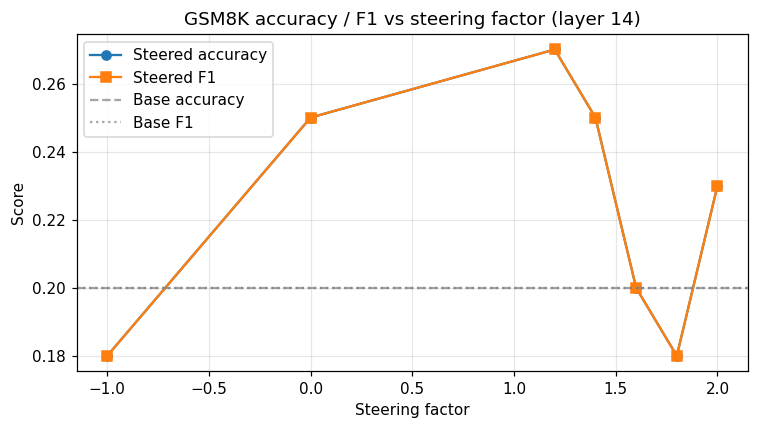

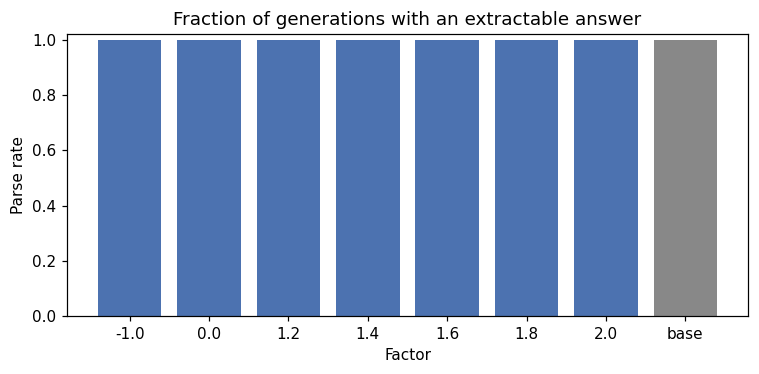

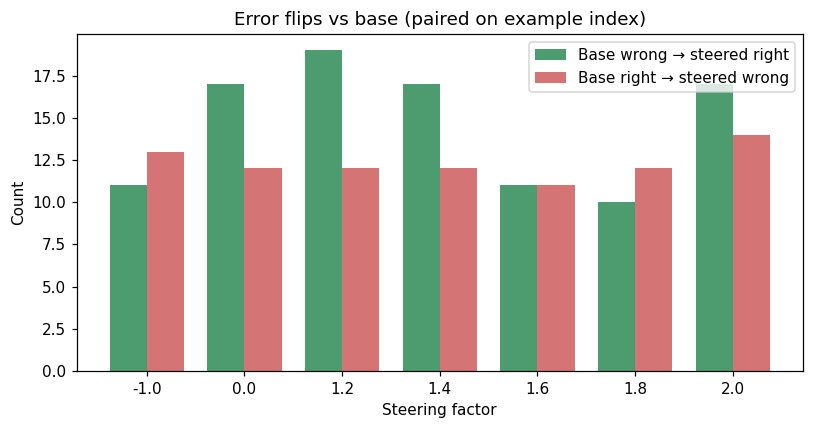

Saved 188 flip records to confusion_flips.json


In [13]:
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 110

sorted_factors = sorted(FACTORS)
acc = [all_metrics[f"steered_{f}"]["accuracy"] for f in sorted_factors]
f1s = [all_metrics[f"steered_{f}"]["f1"] for f in sorted_factors]
pr = [all_metrics[f"steered_{f}"]["parse_rate"] for f in sorted_factors]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(sorted_factors, acc, marker="o", label="Steered accuracy")
ax.plot(sorted_factors, f1s, marker="s", label="Steered F1")
ax.axhline(base_metrics["accuracy"], ls="--", color="gray", alpha=0.7, label="Base accuracy")
ax.axhline(base_metrics["f1"], ls=":", color="gray", alpha=0.7, label="Base F1")
ax.set_xlabel("Steering factor")
ax.set_ylabel("Score")
ax.set_title(f"GSM8K accuracy / F1 vs steering factor (layer {LAYER})")
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(RESULTS_DIR / "accuracy_f1_vs_factor.png")
plt.show()

fig, ax = plt.subplots(figsize=(7, 3.5))
labels_pr = [str(f) for f in sorted_factors] + ["base"]
values_pr = pr + [base_metrics["parse_rate"]]
colors = ["#4c72b0"] * len(sorted_factors) + ["#888"]
ax.bar(labels_pr, values_pr, color=colors)
ax.set_ylim(0, 1.02)
ax.set_ylabel("Parse rate")
ax.set_xlabel("Factor")
ax.set_title("Fraction of generations with an extractable answer")
fig.tight_layout()
fig.savefig(RESULTS_DIR / "parse_rate.png")
plt.show()

# Gained / lost vs base (paired by index).
base_by_idx = {r["idx"]: r["correct"] for r in base_results}
gained, lost, labels = [], [], []
flip_table = []
for f in sorted_factors:
    name = f"steered_{f}"
    res = all_results[name]
    g = sum(1 for r in res if not base_by_idx.get(r["idx"], False) and r["correct"])
    l = sum(1 for r in res if base_by_idx.get(r["idx"], False) and not r["correct"])
    gained.append(g)
    lost.append(l)
    labels.append(str(f))
    for r in res:
        was = base_by_idx.get(r["idx"], False)
        if was != r["correct"]:
            flip_table.append({
                "factor": f,
                "idx": r["idx"],
                "base_correct": was,
                "steered_correct": r["correct"],
                "ground_truth": r["ground_truth"],
                "steered_pred": r["predicted"],
            })

x = np.arange(len(labels))
w = 0.38
fig, ax = plt.subplots(figsize=(7.5, 4))
ax.bar(x - w / 2, gained, w, label="Base wrong → steered right", color="seagreen", alpha=0.85)
ax.bar(x + w / 2, lost, w, label="Base right → steered wrong", color="indianred", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_xlabel("Steering factor")
ax.set_ylabel("Count")
ax.set_title("Error flips vs base (paired on example index)")
ax.legend()
fig.tight_layout()
fig.savefig(RESULTS_DIR / "gained_lost.png")
plt.show()

(RESULTS_DIR / "confusion_flips.json").write_text(json.dumps(flip_table, indent=2))
print(f"Saved {len(flip_table)} flip records to confusion_flips.json")

## 14. Optional: 300-500 example scale-up

The default sweep above runs on 100 examples for speed. This optional section
re-runs every arm on a larger paired subset (300-500 examples) so the reported
accuracy deltas have tighter confidence intervals. Outputs go to
`nb_results_large/` so the 100-example artifacts are untouched.

Gated by `RUN_LARGE = True`; leave False to skip.


In [ ]:
RUN_LARGE = False  # flip to True to execute the scale-up
LARGE_MAX_EXAMPLES = 300  # editable; 300-500 recommended
LARGE_RESULTS_DIR = Path("nb_results_large")

if RUN_LARGE:
    LARGE_RESULTS_DIR.mkdir(exist_ok=True)
    # Re-sample a larger paired subset with the same seed pattern.
    _rng_large = np.random.default_rng(SEED)
    _idx_large = sorted(
        _rng_large.choice(len(_ds_full),
                          size=min(LARGE_MAX_EXAMPLES, len(_ds_full)),
                          replace=False).tolist()
    )
    ds_large = _ds_full.select(_idx_large)
    examples_large = [
        {"question": row["question"],
         "ground_truth": extract_gsm8k_answer(row["answer"]),
         "answer_full": row["answer"]}
        for row in ds_large
    ]

    # Rough runtime estimate: ~8 s / example observed on the 100-example run.
    n_arms = 1 + len(FACTORS)  # base + each factor
    estimated_minutes = (LARGE_MAX_EXAMPLES * n_arms * 8) / 60
    print(f"RUN_LARGE=True with {LARGE_MAX_EXAMPLES} examples x {n_arms} arms "
          f"-> ~{estimated_minutes:.0f} min estimated")

    def _eval_large(label, strength):
        _reseed()
        handles = []
        if strength is not None:
            handles = register_steering(model, LAYER, _vec_tensor, strength)
        results = []
        try:
            for i, ex in enumerate(tqdm(examples_large, desc=f"large:{label}")):
                prompt = f"Question: {ex['question']}\n\nLet's think step by step.\n\n"
                text = generate_once(prompt)
                pred = extract_gsm8k_answer(text)
                ok = is_correct(pred, ex["ground_truth"])
                results.append({
                    "idx": i, "question": ex["question"],
                    "ground_truth": ex["ground_truth"],
                    "predicted": pred, "correct": ok,
                    "full_output": text[-1000:],
                })
        finally:
            remove_hooks(handles)
        return results, compute_metrics(results)

    def _save_large(label, results, metrics, extra=None):
        (LARGE_RESULTS_DIR / f"{label}_results.json").write_text(json.dumps(results, indent=2))
        (LARGE_RESULTS_DIR / f"{label}_generations.txt").write_text(
            "\n\n====\n\n".join(
                f"[{r['idx']}] gt={r['ground_truth']} pred={r['predicted']} correct={r['correct']}\n{r['full_output']}"
                for r in results
            )
        )
        state = {
            "label": label, "model": MODEL_NAME, "layer": LAYER, "seed": SEED,
            "max_examples": len(examples_large), "max_new_tokens": MAX_NEW_TOKENS,
            "temperature": TEMPERATURE, "device": DEVICE, "metrics": metrics,
        }
        if extra:
            state.update(extra)
        (LARGE_RESULTS_DIR / f"{label}_state.json").write_text(json.dumps(state, indent=2))

    large_results = {}
    large_metrics = {}

    base_l_cache = LARGE_RESULTS_DIR / "base_results.json"
    if base_l_cache.exists() and not FORCE_RERUN:
        large_results["base"] = json.loads(base_l_cache.read_text())
        large_metrics["base"] = compute_metrics(large_results["base"])
    else:
        res, met = _eval_large("base", strength=None)
        _save_large("base", res, met)
        large_results["base"] = res
        large_metrics["base"] = met
    print(f"large/base: acc={large_metrics['base']['accuracy']:.3f}")

    for factor in FACTORS:
        label = f"steered_{factor}"
        cache = LARGE_RESULTS_DIR / f"{label}_results.json"
        if cache.exists() and not FORCE_RERUN:
            res = json.loads(cache.read_text())
            met = compute_metrics(res)
        else:
            res, met = _eval_large(label, strength=factor - 1.0)
            _save_large(label, res, met, extra={
                "factor": factor, "strength": factor - 1.0,
                "vector_type": steering_cfg["vector_type"],
                "vector_norm": steering_cfg["vector_norm"],
                "timestamp": time.strftime("%Y-%m-%dT%H:%M:%S"),
            })
        large_results[label] = res
        large_metrics[label] = met
        print(f"large/{label}: acc={met['accuracy']:.3f}")
else:
    print("RUN_LARGE=False — skipped. Flip the toggle above to execute.")


In [ ]:
if RUN_LARGE:
    import matplotlib.pyplot as plt
    plt.rcParams["figure.dpi"] = 110

    sorted_factors_l = sorted(FACTORS)
    acc_l = [large_metrics[f"steered_{f}"]["accuracy"] for f in sorted_factors_l]
    f1_l  = [large_metrics[f"steered_{f}"]["f1"]       for f in sorted_factors_l]
    pr_l  = [large_metrics[f"steered_{f}"]["parse_rate"] for f in sorted_factors_l]
    base_l = large_metrics["base"]

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(sorted_factors_l, acc_l, marker="o", label="Steered accuracy")
    ax.plot(sorted_factors_l, f1_l, marker="s", label="Steered F1")
    ax.axhline(base_l["accuracy"], ls="--", color="gray", label="Base accuracy")
    ax.set_xlabel("Steering factor"); ax.set_ylabel("Score")
    ax.set_title(f"GSM8K accuracy / F1 vs factor (large, n={LARGE_MAX_EXAMPLES})")
    ax.grid(alpha=0.3); ax.legend(); fig.tight_layout()
    fig.savefig(LARGE_RESULTS_DIR / "accuracy_f1_vs_factor_large.png")
    plt.show()

    fig, ax = plt.subplots(figsize=(7, 3.5))
    labels_pr = [str(f) for f in sorted_factors_l] + ["base"]
    values_pr = pr_l + [base_l["parse_rate"]]
    ax.bar(labels_pr, values_pr, color=["#4c72b0"] * len(sorted_factors_l) + ["#888"])
    ax.set_ylim(0, 1.02); ax.set_ylabel("Parse rate")
    ax.set_title(f"Parse rate (large, n={LARGE_MAX_EXAMPLES})")
    fig.tight_layout(); fig.savefig(LARGE_RESULTS_DIR / "parse_rate_large.png")
    plt.show()

    base_by_idx = {r["idx"]: r["correct"] for r in large_results["base"]}
    gained, lost, labels_l = [], [], []
    for f in sorted_factors_l:
        res = large_results[f"steered_{f}"]
        g = sum(1 for r in res if not base_by_idx.get(r["idx"], False) and r["correct"])
        l = sum(1 for r in res if base_by_idx.get(r["idx"], False) and not r["correct"])
        gained.append(g); lost.append(l); labels_l.append(str(f))

    x = np.arange(len(labels_l)); w = 0.38
    fig, ax = plt.subplots(figsize=(7.5, 4))
    ax.bar(x - w/2, gained, w, label="base wrong -> steered right", color="seagreen", alpha=0.85)
    ax.bar(x + w/2, lost,   w, label="base right -> steered wrong", color="indianred", alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(labels_l)
    ax.set_xlabel("Steering factor"); ax.set_ylabel("Count")
    ax.set_title(f"Error flips vs base (large, n={LARGE_MAX_EXAMPLES})")
    ax.legend(); fig.tight_layout()
    fig.savefig(LARGE_RESULTS_DIR / "gained_lost_large.png")
    plt.show()
else:
    print("RUN_LARGE=False — plots skipped.")


## 13. Bundle everything and (optionally) download

In [14]:
import zipfile
zip_path = Path(f"nb_results_{RUN_TAG}.zip")
if zip_path.exists():
    zip_path.unlink()
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for p in RESULTS_DIR.rglob("*"):
        if p.is_file():
            zf.write(p, arcname=p.relative_to(RESULTS_DIR.parent))
    # If the optional RUN_LARGE arm produced outputs, include them too.
    if 'LARGE_RESULTS_DIR' in globals() and Path(LARGE_RESULTS_DIR).exists():
        for p in Path(LARGE_RESULTS_DIR).rglob("*"):
            if p.is_file():
                zf.write(p, arcname=p.relative_to(Path(LARGE_RESULTS_DIR).parent))
print(f"Zipped {zip_path} ({zip_path.stat().st_size / 1024:.1f} KB)")

try:
    from google.colab import files  # type: ignore
    files.download(str(zip_path))
except Exception:
    print("Not on Colab \u2014 the zip is on the local filesystem.")


Zipped nb_results.zip (526.4 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>